# **Method (03) - image_dataset_from_directory()**
- High-level shortcut
- Automatically:
  - reads folders
  - labels images
  - batches data
- Built on top of tf.data

In [1]:
import tensorflow as tf

In [11]:
# create Dataset obj that bactched into 32, image size 256 

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    shuffle=True,
    image_size=256,
    batch_size=32
)

Found 2152 files belonging to 3 classes.


In [3]:
classes = dataset.class_names
classes

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [5]:
len(dataset) # no of bacthes

68

In [32]:
for i in dataset.take(1):
    print(len(i))      # two items in tuple
    print(i[0].shape)  # first item shape 32 batches of metrices 2567 x 256 x 3
    print(i[1].shape)  # label batch shape
    print(i[1])        # check lables dataset is shuffled

2
(32, 256, 256, 3)
(32,)
tf.Tensor([1 2 1 0 0 0 1 0 1 0 2 0 2 0 0 1 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 0], shape=(32,), dtype=int32)


## Train test splitting

In [13]:
n = len(dataset)

train_size = int(n*0.7)
val_size = int(n*0.2)
test_size = int(n*0.1)

In [17]:
train_ds = dataset.take(train_size)
val_ds = dataset.take(val_size)
test_ds = dataset.take(test_size)

print(len(train_ds), len(val_ds), len(test_ds)) # len is in bactches

47 13 6


## First image in first batch

In [18]:
import matplotlib.pyplot as plt

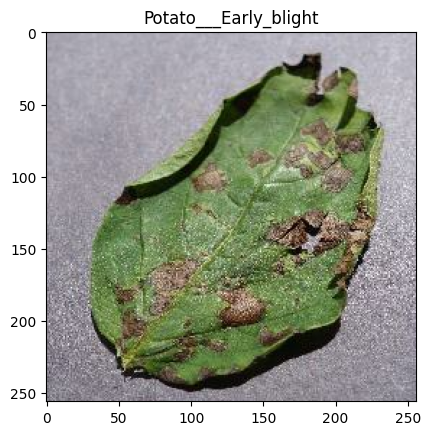

In [33]:
for i_batch, l_batch in train_ds.take(1):
    plt.imshow(i_batch[0].numpy().astype('uint8'))
    plt.title(classes[l_batch[0].numpy()]) # clas int values are in order that given by datset.classes